In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PARQUET_DIR = Path.home() / "projects" / "recsys" / "data" / "parquet"

ratings = pd.read_parquet(PARQUET_DIR / "ratings.parquet")
movies = pd.read_parquet(PARQUET_DIR / "movies.parquet")

print("ratings shape:", ratings.shape)
print("ratings memory:", ratings.memory_usage(deep=True).sum() / 1e6, "mb")
print("\nratings head:")
print(ratings.head())
print("\nratings dtypes:")
print(ratings.dtypes)
print("\nmovies shape:", movies.shape)
print("\nmovies head:")
print(movies.head())

ratings shape: (25000095, 4)
ratings memory: 800.003172 mb

ratings head:
   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510

ratings dtypes:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

movies shape: (62423, 3)

movies head:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|R

In [2]:
print("before:")
print(ratings.dtypes)
print(f"memory: {ratings.memory_usage(deep=True).sum() / 1e6:.1f} mb\n")

# check max values to confirm int32 fits
print("max userId:", ratings["userId"].max())
print("max movieId:", ratings["movieId"].max())
print("max timestamp:", ratings["timestamp"].max())
print("rating range:", ratings["rating"].min(), "to", ratings["rating"].max())
print()

# int32 max is ~2.1 billion, plenty of room
ratings = ratings.astype({
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int32",
})

print("after:")
print(ratings.dtypes)
print(f"memory: {ratings.memory_usage(deep=True).sum() / 1e6:.1f} mb")

before:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
memory: 800.0 mb

max userId: 162541
max movieId: 209171
max timestamp: 1574327703
rating range: 0.5 to 5.0

after:
userId         int32
movieId        int32
rating       float32
timestamp      int32
dtype: object
memory: 400.0 mb


In [3]:
# basic stats
print("rating stats:")
print(ratings["rating"].describe())
print()

# value counts (how many of each rating)
print("rating distribution:")
counts = ratings["rating"].value_counts().sort_index()
print(counts)
print()

# percentages
print("rating percentages:")
pcts = (counts / len(ratings) * 100).round(2)
print(pcts)

rating stats:
count    2.500010e+07
mean     3.533854e+00
std      1.060744e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

rating distribution:
rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64

rating percentages:
rating
0.5     1.57
1.0     3.11
1.5     1.60
2.0     6.56
2.5     5.05
3.0    19.59
3.5    12.71
4.0    26.56
4.5     8.80
5.0    14.45
Name: count, dtype: float64


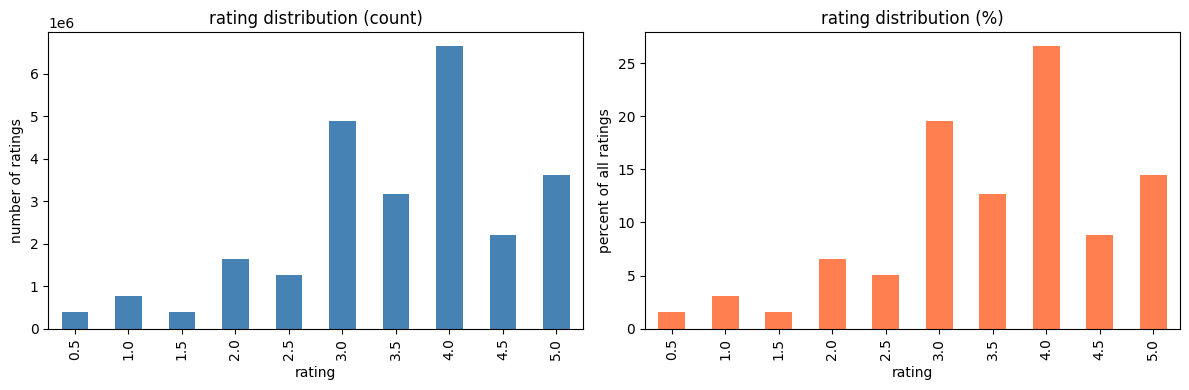


mean rating: 3.534
median rating: 3.5
% of ratings >= 4.0: 49.8%
% of ratings == 5.0: 14.4%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("rating distribution (count)")
ax[0].set_xlabel("rating")
ax[0].set_ylabel("number of ratings")

pcts.plot(kind="bar", ax=ax[1], color="coral")
ax[1].set_title("rating distribution (%)")
ax[1].set_xlabel("rating")
ax[1].set_ylabel("percent of all ratings")

plt.tight_layout()
plt.show()

print(f"\nmean rating: {ratings['rating'].mean():.3f}")
print(f"median rating: {ratings['rating'].median():.1f}")
print(f"% of ratings >= 4.0: {(ratings['rating'] >= 4.0).mean() * 100:.1f}%")
print(f"% of ratings == 5.0: {(ratings['rating'] == 5.0).mean() * 100:.1f}%")

selection bias. users only rate movies they bothered watching. there's no data for "users who didn't watch this and would have hated it." this is huge. it's why netflix doesn't predict ratings anymore.
explicit feedback is weak signal. in production, every recsys at scale (youtube, tiktok, instagram) uses implicit feedback: watched, clicked, skipped. movielens ratings are explicit feedback, useful for learning but not how you'd build a real system today.
rating prediction is the wrong objective. the famous netflix prize ($1m, 2009) was about rmse on rating prediction. netflix never deployed the winning model. they realized ranking matters more than predicted score. this is the modern recsys mindset.

user activity stats (ratings per user):
count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
dtype: float64

how many users have rated:
  >= 20 ratings:  162,541 users (100.0%)
  >= 100 ratings:  63,892 users (39.3%)
  >= 500 ratings:   9,713 users (6.0%)
  exactly 1:            0 users

top 1% of users contribute: 12.1% of all ratings
bottom 50% of users contribute: 12.6% of all ratings


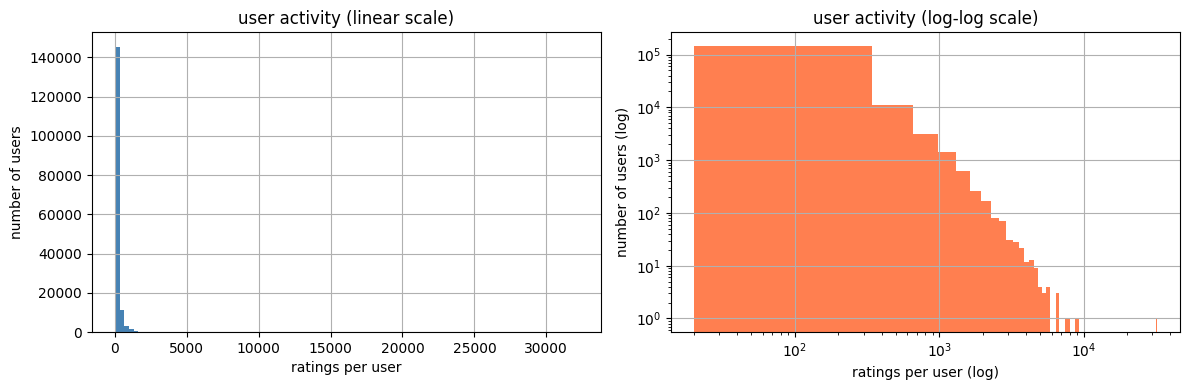

In [5]:
user_counts = ratings.groupby("userId").size()

print("user activity stats (ratings per user):")
print(user_counts.describe())
print()

print("how many users have rated:")
print(f"  >= 20 ratings:  {(user_counts >= 20).sum():>7,} users ({(user_counts >= 20).mean() * 100:.1f}%)")
print(f"  >= 100 ratings: {(user_counts >= 100).sum():>7,} users ({(user_counts >= 100).mean() * 100:.1f}%)")
print(f"  >= 500 ratings: {(user_counts >= 500).sum():>7,} users ({(user_counts >= 500).mean() * 100:.1f}%)")
print(f"  exactly 1:      {(user_counts == 1).sum():>7,} users")
print()

print(f"top 1% of users contribute: {user_counts.nlargest(int(len(user_counts) * 0.01)).sum() / len(ratings) * 100:.1f}% of all ratings")
print(f"bottom 50% of users contribute: {user_counts.nsmallest(int(len(user_counts) * 0.5)).sum() / len(ratings) * 100:.1f}% of all ratings")

# plot on log scale (long tail)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

user_counts.hist(bins=100, ax=ax[0], color="steelblue")
ax[0].set_title("user activity (linear scale)")
ax[0].set_xlabel("ratings per user")
ax[0].set_ylabel("number of users")

user_counts.hist(bins=100, ax=ax[1], color="coral")
ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_title("user activity (log-log scale)")
ax[1].set_xlabel("ratings per user (log)")
ax[1].set_ylabel("number of users (log)")

plt.tight_layout()
plt.show()

min is 20, no users with exactly 1. movielens pre-filters: only users with ≥20 ratings are kept. real production systems can't do this. they have millions of brand-new users with 0-3 interactions. this gap between "research datasets" and "production reality" is huge. flag this in your writeup.
mean 154, median 71, max 32,202. mean far above median = right-skewed long tail. one user rated 32k movies, that's roughly 4 movies a day every day for 22 years. these power users distort everything if you don't handle them.
top 1% contribute 12% of data, bottom 50% contribute 13%. less extreme than i expected (movielens is filtered), but still: a tiny minority drives a disproportionate share of signal.
39% of users have 100+ ratings, 6% have 500+. when you train a two-tower model, the signal from long-tail users is weak. cold-start handling becomes a core design problem.

movie popularity stats (ratings per movie):
count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
dtype: float64

how many movies have:
  >= 1000 ratings:   3,794 movies
  >= 100 ratings:   10,326 movies
  >= 10 ratings:    24,330 movies
  exactly 1 rating: 10,298 movies
  total movies in catalog: 62,423
  movies with no ratings:  3,376

top 1% of movies (590 films) capture 47.6% of all ratings

top 10 most-rated movies:
                                    title  num_ratings
                      Forrest Gump (1994)        81491
         Shawshank Redemption, The (1994)        81482
                      Pulp Fiction (1994)        79672
         Silence of the Lambs, The (1991)        74127
                       Matrix, The (1999)        72674
Star Wars: Episode IV - A New Hope (1977)        68717
                     Jurassic Park (1993)        64144
             

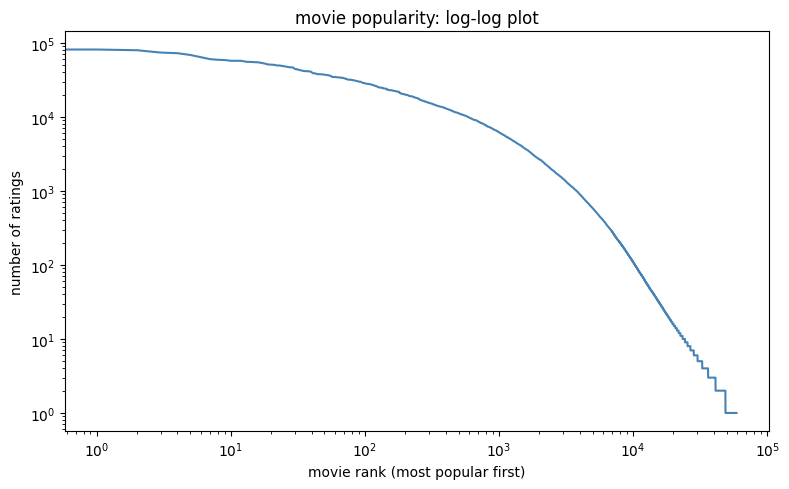

In [6]:
movie_counts = ratings.groupby("movieId").size()

print("movie popularity stats (ratings per movie):")
print(movie_counts.describe())
print()

# how many movies are in the long tail
print("how many movies have:")
print(f"  >= 1000 ratings:  {(movie_counts >= 1000).sum():>6,} movies")
print(f"  >= 100 ratings:   {(movie_counts >= 100).sum():>6,} movies")
print(f"  >= 10 ratings:    {(movie_counts >= 10).sum():>6,} movies")
print(f"  exactly 1 rating: {(movie_counts == 1).sum():>6,} movies")
print(f"  total movies in catalog: {len(movies):,}")
print(f"  movies with no ratings:  {len(movies) - movie_counts.shape[0]:,}")
print()

# top 1% of movies
top_pct = int(len(movie_counts) * 0.01)
top_movies_share = movie_counts.nlargest(top_pct).sum() / len(ratings) * 100
print(f"top 1% of movies ({top_pct} films) capture {top_movies_share:.1f}% of all ratings")

# what are the top 10 most-rated movies
top10_ids = movie_counts.nlargest(10).index
top10 = movies[movies["movieId"].isin(top10_ids)].merge(
    movie_counts.rename("num_ratings"), left_on="movieId", right_index=True
).sort_values("num_ratings", ascending=False)

print("\ntop 10 most-rated movies:")
print(top10[["title", "num_ratings"]].to_string(index=False))

# log-log plot to see if it's a power law
fig, ax = plt.subplots(figsize=(8, 5))
movie_counts.sort_values(ascending=False).reset_index(drop=True).plot(
    ax=ax, color="steelblue"
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title("movie popularity: log-log plot")
ax.set_xlabel("movie rank (most popular first)")
ax.set_ylabel("number of ratings")
plt.tight_layout()
plt.show()

if you just recommend popular movies to everyone, you have a working baseline. but you also have netflix in 2005: every user gets the same 100 movies, the long tail dies, the platform becomes boring. the entire job of a recsys is to match users to the long tail — surface the right obscure movie to the right person. retrieving from popular items is easy. retrieving from the tail is the actual problem. this is why two-tower models and ann (approximate nearest neighbor) exist.

time range of ratings:
  earliest: 1995-01-09 11:46:49
  latest:   2019-11-21 09:15:03
  span:     24.9 years

ratings per year:
year
1995          3
1996    1430093
1997     626202
1998     272099
1999    1059080
2000    1735398
2001    1058750
2002     776654
2003     920295
2004    1048116
2005    1613550
2006    1038458
2007     931432
2008    1018001
2009     810127
2010     792436
2011     676498
2012     635208
2013     515684
2014     478270
2015    1604971
2016    1757440
2017    1689935
2018    1310761
2019    1200634
dtype: int64


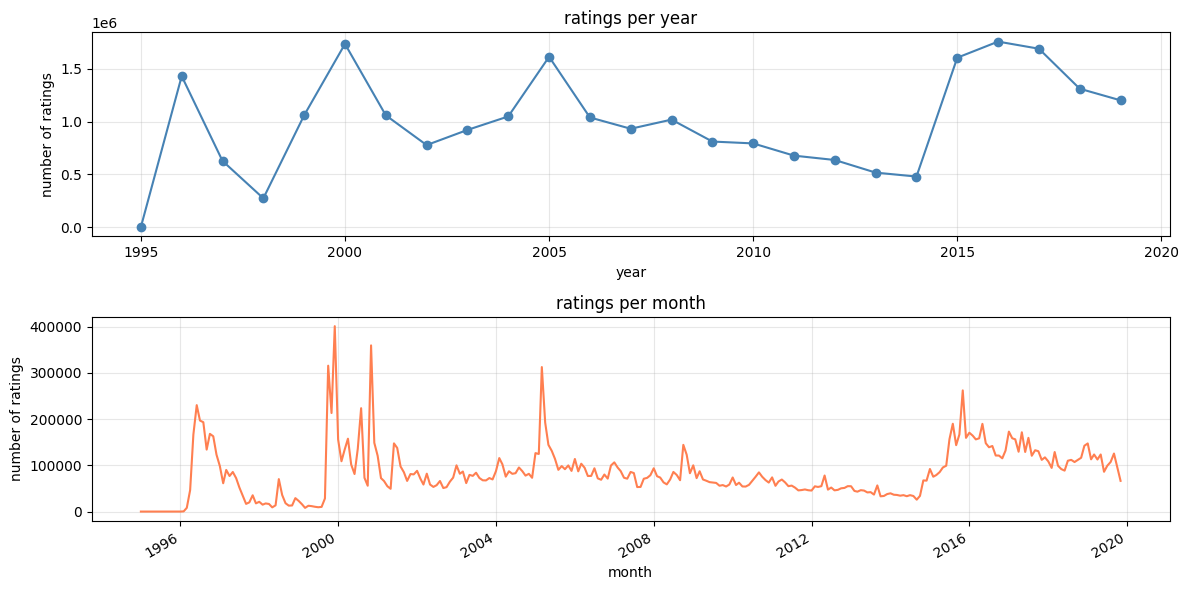


mean rating by year:
year
1995    3.667
1996    3.546
1997    3.588
1998    3.513
1999    3.617
2000    3.575
2001    3.532
2002    3.486
2003    3.477
2004    3.431
2005    3.434
2006    3.467
2007    3.472
2008    3.538
2009    3.506
2010    3.528
2011    3.555
2012    3.615
2013    3.653
2014    3.611
2015    3.557
2016    3.531
2017    3.546
2018    3.564
2019    3.576
Name: rating, dtype: float32


In [7]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"] = ratings["datetime"].dt.year
ratings["month"] = ratings["datetime"].dt.to_period("M")

print("time range of ratings:")
print(f"  earliest: {ratings['datetime'].min()}")
print(f"  latest:   {ratings['datetime'].max()}")
print(f"  span:     {(ratings['datetime'].max() - ratings['datetime'].min()).days / 365:.1f} years")
print()

per_year = ratings.groupby("year").size()
print("ratings per year:")
print(per_year)

fig, ax = plt.subplots(2, 1, figsize=(12, 6))

per_year.plot(ax=ax[0], color="steelblue", marker="o")
ax[0].set_title("ratings per year")
ax[0].set_ylabel("number of ratings")
ax[0].grid(alpha=0.3)

per_month = ratings.groupby("month").size()
per_month.index = per_month.index.to_timestamp()
per_month.plot(ax=ax[1], color="coral")
ax[1].set_title("ratings per month")
ax[1].set_ylabel("number of ratings")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# rating quality over time
yearly_mean = ratings.groupby("year")["rating"].mean()
print("\nmean rating by year:")
print(yearly_mean.round(3))

data volume is uneven across years (272k to 1.7m). user populations shift over time (cohort effect). a temporal split (train pre-2018, test 2018-2019) is the realistic evaluation: it tests both temporal generalization and partial cold start, since some 2018 users will have history and others won't. random split is unrealistic and inflates metrics.